# Raster data preparations

In this exercise, the raster data for the classification excercises is prepared. 

This workbook requires at least 6Gb memory. 1 core is enough, but xarray could use more, if working with bigger datasets.

For machine learning tasks, the input raster data must follow these rules.

1) Data and labels images must align, so that they have the same:
* Coordinate system
* Resolution / pixel size
* Data origin (min x and y), so that one pixel in both files covers exactly the same area.

*Note, in CNN exercise we use `Torchgeo` package, that could do this aligning itself on-the-fly.*

2) Labels image must be a raster image of type Integer and 1 band. The class numbers start from 0 and grow to `number_of_classes - 1`. So for binary classification the labels image has values 0 and 1. For 4 class multiclass labels, values 0 to 3. If needed, vector labels need to be rasterized.

3) Data image must be of type Float with values between 0 and 1 (sometimes -1 to 1), may have several bands, usually has.

Here we prepare labels for all data image area, for pixel-wise machine learning, data could be prepared also for specific points/pixels only. See for example: [SYKE land use classification with LUCAS points](https://geohpc.readthedocs.io/en/latest/lessons/L3/03_LandCoverClassification_syke_Parallelization.html)

Thanks to Mikko Kervinen (SYKE) for providing update to an earlier version of this exercise, changing from unmaintained `stackstac`-library to `odc-stac`.

## Data sources

#### Labels:
Data sources: 
* Finnish Food Authority, [Agricultural parcels](https://www.paikkatietohakemisto.fi/geonetwork/srv/eng/catalog.search#/metadata/e4467d0b-51f9-41f2-bd7e-8ff48a2cb083). Data downloaded from [GeoPortti GeoCubes](https://vm0160.kaj.pouta.csc.fi/geocubes/). Agricultural parcels are originally vector data, but have been rasterized to GeoCubes.
* LUKE, [MVMI forest inventory, site main class](http://urn.fi/urn:nbn:fi:fd-849cabd2-0ae5-3455-b6f3-a39086cce33c). Data downloaded from [Paituli](https://paituli.csc.fi/).
* SYKE, [CORINE](https://www.paikkatietohakemisto.fi/geonetwork/srv/eng/catalog.search#/metadata/%7B0B4B2FAC-ADF1-43A1-A829-70F02BF0C0E5%7D). Data downloaded from [GeoPortti GeoCubes](https://vm0160.kaj.pouta.csc.fi/geocubes/).

The advantage of useing GeoCubes is that there all data is pre-processed so that it fits the requirements mentioned above. 

#### Data image:
* FMI, [10-days Sentinel2 mosaic](https://ckan.ymparisto.fi/dataset/sentinel-2-satellite-image-mosaics-s2gm-sentinel-2-satelliittikuvamosaiikki-s2gm), original images from ESA.
* Google, [AlphaEarth](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL).


All datasets used for this exercise have already same coordinate system (EPSG:3067), except AlphaEarth. The `odc-stac` package takes care of harmonizing data origin and resolution (20m).

For finding the files [Paituli STAC](https://paituli.csc.fi/stac.html) is used. For longer intro to STAC and its usege see [CSC STAC examples](https://github.com/csc-training/geocomputing/tree/master/python/STAC).

## Data processing results

The goal of this exercise is to have 9 raster files:
* Pixel-wise models (will be later split to training, validation and test)
    * Labels
    * Sentinel-2 data
    * AlphaEarth data 
* CNN: separate areas for training, validation and test.
    * Labels, x3 extents
    * Sentinel-2 data, x3 extents
* All files:
    * Coordinate system: Finnish ETRS-TM35FIN, EPSG:3067
    * Resolution: 20m

#### Labels

Multiclass classification raster: 
* 1 - forest from forest inventory data
* 2 - fields from agricultural parcels data
* 3 - water from CORINE land cover data
* 0 - everything else 

#### Data image

* Sentinel2 mosaic, we include data from 2 different dates (May and July), to have more data values. Final dataset has 8 bands based on bands: 2, 3, 4 and 8 on dates: 2021-05-11 and 2021-07-21, reflection values scaled to [0 ... 1]. The bands source data is: 
     *  'b02' / '2021-05-11'
     *  'b02' / '2021-07-21'
     *  'b03' / '2021-05-11'
     *  'b03' / '2021-07-21'
     *  'b04' / '2021-05-11'
     *  'b04' / '2021-07-21'
     *  'b08' / '2021-05-11'
     *  'b08' / '2021-07-21'
* AlphaEarth, 64 channels, data from 2021. 

## Data processing main steps
* Set STAC specs, file names and bbox extents for different files
* Connect to STAC catalog and define function to fetch data via STAC

### Labels

1) Fetch original datasets via Paituli STAC and explore them.
2) Create a new labels dataset and calculate class values based on the original datasets
3) Save data to 4 files with different extents.

### Data image
#### Sentinel-2 data
1) Fetch Sentinel-2 11-day mosaics via Paituli STAC, including only required bands
3) Normalize the data values, the reflectance values are originally between 0 and 1, but for storage they have been multiplied with 10 000, so here the normalization is simple division with 10 000.
4) Stack data from different dates just as bands.
3) Save data to 4 files with different extents.

#### AlphaEarth data
1) Download the data for correct bbox, coordinate system and pixel size. Only for pixel-wise models.

## Imports and paths

In [1]:
import os
import numpy as np

# Handling raster data
import rioxarray
import xarray

# Plotting
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import pandas as pd

# STAC search and data fetching
import pyproj
import pystac_client
from odc.stac import stac_load
from odc.geo.geobox import GeoBox
#import yaml
#import rasterio

# Bbox creation for plotting the extents
import geopandas as gpd
from shapely.geometry import Polygon

Set STAC specs for all datasets: collcetion_id, time-period and names of assets.

Use [STAC browser](https://radiantearth.github.io/stac-browser/#/external/paituli.csc.fi/geoserver/ogc/stac/v1?.language=en) to find suitable datasets and their specs: 
* The collection ID is available behind I-source button.
* Asset names, select a random item and see the left pane.
* Available time, see Temporal Extent in STAC browser, use STAC search or look from GeoCubes or Paituli services, which years are available.

In [2]:
# Paituli STAC
stac_endpoint = "https://paituli.csc.fi/geoserver/ogc/stac/v1"

# Fields 
fields_stac_id = "land_parcels_at_geocubes"
fields_time = "2016-07-01"
fields_assets = ["20m"]

# CORINE
corine_stac_id = "corine_land_cover_at_geocubes"
corine_time = "2018-07-01"
corine_assets = ["20m"]

# Forest
forest_stac_id = "luke_vmi_paatyyppi_at_paituli" 
forest_time = "2023-07-01"
forest_assets = ["luke_vmi_paatyyppi_at_paituli_tiff"]

# Sentinel-2 11-day mosaic
sentinel2_stac_id = "sentinel_2_11_days_mosaics_at_fmi"
sentinel2_time1 = "2021-05-11"
sentinel2_time2 = "2021-07-21"
sentinel2_assets = ['b02', 'b03', 'b04', 'b08']

Set folder and file names.

In [3]:
base_folder = os.path.join(os.sep, 'scratch', 'project_2019932', 'students', os.environ.get('USER'), 'GeoML')

#exercise_folder = os.path.join(base_folder, '02_raster_data_preparation') 
#os.makedirs(exercise_folder, exist_ok=True)
data_folder = os.path.join(base_folder,'data', 'raster')
if not os.path.isdir(data_folder):
    os.makedirs(data_folder)

pixel_wise_folder = os.path.join(data_folder,'pixel-wise')
os.makedirs(pixel_wise_folder, exist_ok=True)
cnn_folder = os.path.join(data_folder,'cnn')
os.makedirs(cnn_folder, exist_ok=True)

data_sentinel2 = os.path.join(pixel_wise_folder, 'data_sentinel2.tif')
cnn_data_training = os.path.join(cnn_folder, 'data_training.tif')
cnn_data_test = os.path.join(cnn_folder, 'data_test.tif')
cnn_data_validation = os.path.join(cnn_folder, 'data_validation.tif')

data_alphaearth = os.path.join(pixel_wise_folder, 'data_alphaearth.tif')

labels_pixel_wise = os.path.join(pixel_wise_folder, 'labels.tif')
cnn_labels_training = os.path.join(cnn_folder, 'labels_training.tif')
cnn_labels_test = os.path.join(cnn_folder, 'labels_test.tif')
cnn_labels_validation = os.path.join(cnn_folder, 'labels_validation.tif')
cnn_labels_test

'/scratch/project_2019932/students/ekkylli/GeoML/data/raster/cnn/labels_test.tif'

### Set extent for different files

Define extents for training, validation and test data. The data is from Southern Finland.

In [4]:
x_min_3067 = 250000
y_min_3067 = 6690000
x_max_3067 = x_min_3067 + 200000 
y_max_3067 = y_min_3067 + 60000
bbox_3067 = (x_min_3067, y_min_3067, x_max_3067, y_max_3067)

x_min_3067_test = x_min_3067
x_max_3067_test = x_min_3067_test + 20000
x_min_3067_deep = x_max_3067_test
x_max_3067_deep = x_max_3067 - 40000
x_min_3067_shallow = x_min_3067_deep 
x_max_3067_shallow = x_min_3067_shallow + 20000
x_min_3067_validation = x_max_3067_deep
x_max_3067_validation = x_max_3067
y_min_3067_shallow = y_min_3067 
y_max_3067_shallow = y_min_3067 + 20000

data_epsg = 3067
data_epsg_string = "EPSG:" + str(data_epsg)

Plot the different extents.

In [5]:
x_point_list_shallow = [x_min_3067_shallow, x_min_3067_shallow, x_max_3067_shallow, x_max_3067_shallow, x_min_3067_shallow]
x_point_list_deep = [x_min_3067_deep, x_min_3067_deep, x_max_3067_deep, x_max_3067_deep, x_min_3067_deep]
x_point_list_validation = [x_min_3067_validation, x_min_3067_validation, x_max_3067_validation, x_max_3067_validation, x_min_3067_validation]
x_point_list_test = [x_min_3067_test, x_min_3067_test, x_max_3067_test, x_max_3067_test, x_min_3067_test]
y_point_list = [y_min_3067, y_max_3067, y_max_3067, y_min_3067, y_min_3067]
y_point_list_shallow = [y_min_3067_shallow, y_max_3067_shallow, y_max_3067_shallow, y_min_3067_shallow, y_min_3067_shallow]

polygon_shallow = Polygon(zip(x_point_list_shallow, y_point_list_shallow))
polygon_deep = Polygon(zip(x_point_list_deep, y_point_list))
polygon_test = Polygon(zip(x_point_list_test, y_point_list))
polygon_validation = Polygon(zip(x_point_list_validation, y_point_list))

#polygons = [polygon_test, polygon_shallow, polygon_deep]
d = {'label': ['deep training', 'shallow', 'deep test', 'deep validation'], 'geometry': [polygon_deep, polygon_shallow, polygon_test, polygon_validation]}
polygons = gpd.GeoDataFrame(d, crs=data_epsg_string)  
polygons.explore(column='label')

## STAC set-up

Open STAC end-point, the queries are done to here.

In [6]:
catalog = pystac_client.Client.open(stac_endpoint)

Function to query STAC catalog with given collection ID, time period and bbox. Fetch the data of found items, for given assets. Resolution (20m) is fixed here, but could be different from original data.

In [7]:
def fetch_stac_layer_with_bbox(catalog, collection_id, assets, time_period, bbox, epsg=3067, resolution=20, chunksize={'x':256,'y':256}, resampling='nearest', cfg = None):

    # Grid definition from bbox and resolution
    AOI = GeoBox.from_bbox(bbox, resolution = resolution, crs=f'EPSG:{epsg}')

    # Search all items between the given dates
    search = catalog.search(
        bbox=AOI.boundingbox.to_crs('epsg:4326').bbox,
        collections=[collection_id],
        datetime=time_period,
    )

    ds = stac_load(
            [item for item in search.item_collection()],
            resampling=resampling,
            dtype='uint16',
            chunks=chunksize,  # <-- force Dask
            geobox = AOI, # defines grid, ie bbox and resolution
            bands = assets,
            stac_cfg=cfg
        )
    
    return ds

## Labels processing

Fetch data via STAC.

In [8]:
forest = fetch_stac_layer_with_bbox(catalog, forest_stac_id, forest_assets, forest_time, bbox_3067, data_epsg)
# data cube is now a xarray Dataset, to match the stackstac output, you can use
# forest = forest.to_dataarray(dim="band").squeeze()
forest

<xarray.Dataset> Size: 60MB
Dimensions:                             (y: 3000, x: 10000, time: 1)
Coordinates:
  * y                                   (y) float64 24kB 6.75e+06 ... 6.69e+06
  * x                                   (x) float64 80kB 2.5e+05 ... 4.5e+05
    spatial_ref                         int32 4B 3067
  * time                                (time) datetime64[ns] 8B 2023-01-01
Data variables:
    luke_vmi_paatyyppi_at_paituli_tiff  (time, y, x) uint16 60MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

In [9]:
fields = fetch_stac_layer_with_bbox(catalog,fields_stac_id, fields_assets, fields_time, bbox_3067, data_epsg)
fields

<xarray.Dataset> Size: 60MB
Dimensions:      (y: 3000, x: 10000, time: 1)
Coordinates:
  * y            (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
  * x            (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
    spatial_ref  int32 4B 3067
  * time         (time) datetime64[ns] 8B 2016-01-01
Data variables:
    20m          (time, y, x) uint16 60MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

In [10]:
corine = fetch_stac_layer_with_bbox(catalog, corine_stac_id, corine_assets, corine_time, bbox_3067, data_epsg)
corine

<xarray.Dataset> Size: 60MB
Dimensions:      (y: 3000, x: 10000, time: 1)
Coordinates:
  * y            (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
  * x            (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
    spatial_ref  int32 4B 3067
  * time         (time) datetime64[ns] 8B 2018-01-01
Data variables:
    20m          (time, y, x) uint16 60MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

### Explore original labels data

Plot small part of the data image.

Text(0.5, 1.0, 'Forest main type')

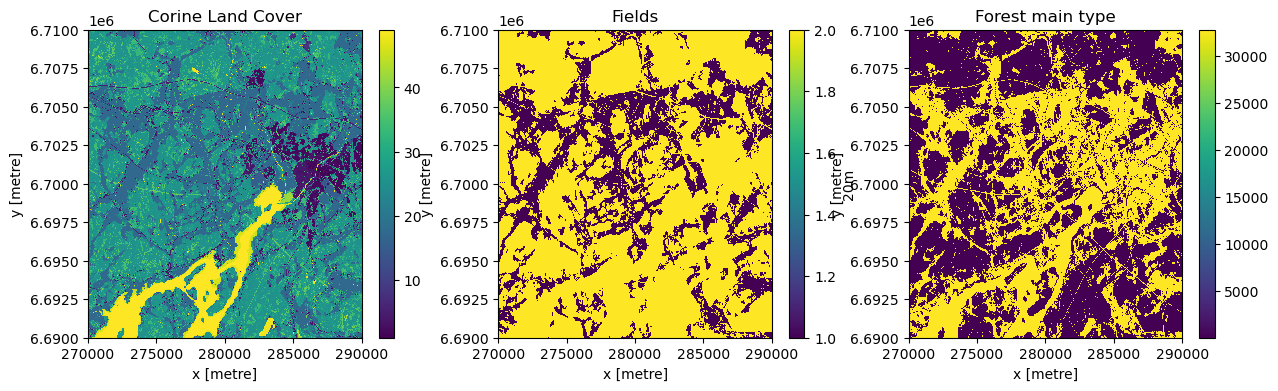

In [11]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(15, 4))
# Now the variables are DataSets instead of DataArrays
# Either convert to dataarray for plotting
corine.isel(x=slice(1000,2000), y=slice(2000,3000)).to_dataarray(dim="band").squeeze().plot(ax=ax[0])
ax[0].set_title("Corine Land Cover")
# or select the variable of interest, in this case name is "20m"
fields["20m"].isel(x=slice(1000,2000), y=slice(2000,3000)).plot(ax=ax[1])
ax[1].set_title("Fields")
forest.isel(x=slice(1000,2000), y=slice(2000,3000)).to_dataarray(dim="band").squeeze().plot(ax=ax[2])
ax[2].set_title("Forest main type")

### Reclassify

Create a new dataset with classification assigned based on the 3 original rasters.

In [12]:
labels = fields.to_dataarray(dim="band").squeeze().copy()
#labels = labels.where(labels != 2, other=0)
labels = xarray.where(labels == 2, 0, labels) # Not-field to 0
labels = xarray.where(labels == 1, 2, labels) # Fields to class 2
labels = xarray.where(forest.to_dataarray(dim="band").squeeze() < 50, 1, labels) # Forest to class 1
labels = xarray.where(corine.to_dataarray(dim="band").squeeze() == 47, 3, labels) # Rivers, to class 3
labels = xarray.where(corine.to_dataarray(dim="band").squeeze() == 48, 3, labels) # Lakes, to class 3
labels = xarray.where(corine.to_dataarray(dim="band").squeeze() == 49, 3, labels) # Sea, to class 3



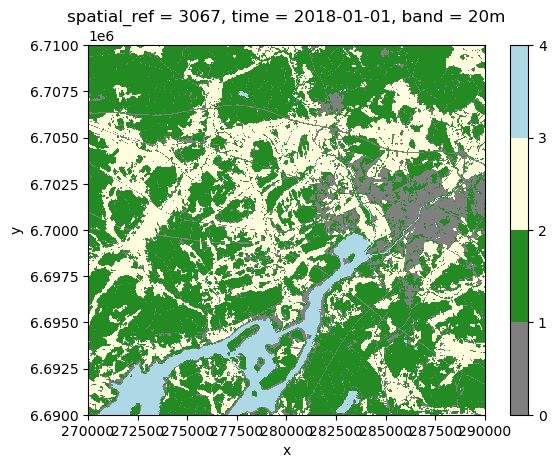

In [13]:
classes = [0, 1, 2, 3]
colors  = ["gray", "forestgreen", "lightyellow", "lightblue"]
cmap = ListedColormap(colors)
class_bounds = np.array(classes + [classes[-1] + 1])   # e.g., [11,12,21,22,23,31,32]
norm = BoundaryNorm(class_bounds, len(colors))
labels.isel(x=slice(1000,2000), y=slice(2000,3000)).plot(cmap=cmap, norm=norm)

See number of pixels in each class.

In [14]:
def get_class_stats(data):
    stats = np.unique(data, return_counts=True)
    df = pd.DataFrame({
        "value": stats[0],
        "count": stats[1]
    })
    return df

In [15]:
labels_stats = get_class_stats(labels)
print("Labels classes:")
labels_stats

Labels classes:


,value,count
0,0,2933809
1,1,17417424
2,2,8336100
3,3,1312667


### Save labels files

Add coordinate system info, as `rioxarray` wants it.

In [16]:
labels.rio.write_crs(data_epsg, inplace=True)

<xarray.DataArray (y: 3000, x: 10000)> Size: 60MB
dask.array<where, shape=(3000, 10000), dtype=uint16, chunksize=(256, 256), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
  * x            (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
    time         datetime64[ns] 8B 2018-01-01
    band         <U3 12B '20m'
    spatial_ref  int64 8B 0

Save the file with 4 different extents for deep and shallow model training, validation and testing.

In [17]:
def save_bbox_to_geotiff(data, minx, miny, maxx, maxy, filename):
    clipped = data.rio.clip_box(minx, miny, maxx, maxy)
    clipped.rio.to_raster(filename, tiled=True, format='COG')

In [18]:
# Deep learning, model training
save_bbox_to_geotiff(labels, x_min_3067_deep, y_min_3067, x_max_3067_deep, y_max_3067, cnn_labels_training)
# Shallow learning, model training
save_bbox_to_geotiff(labels, x_min_3067_shallow, y_min_3067_shallow, x_max_3067_shallow, y_max_3067_shallow, labels_pixel_wise)
# Validation
save_bbox_to_geotiff(labels, x_min_3067_validation, y_min_3067, x_max_3067_validation, y_max_3067, cnn_labels_validation)
# Test
save_bbox_to_geotiff(labels, x_min_3067_test, y_min_3067, x_max_3067_test, y_max_3067, cnn_labels_test)

## Sentinel-2 data image processing

1. Find data using Paituli STAC catalogue, for the whoel time span between te given dates (8 entries)

In [19]:
sentinel2_1 = fetch_stac_layer_with_bbox(catalog, sentinel2_stac_id, sentinel2_assets, f'{sentinel2_time1}/{sentinel2_time2}', bbox_3067, data_epsg, resampling='cubic')
sentinel2_1

<xarray.Dataset> Size: 2GB
Dimensions:      (y: 3000, x: 10000, time: 8)
Coordinates:
  * y            (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
  * x            (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
    spatial_ref  int32 4B 3067
  * time         (time) datetime64[ns] 64B 2021-05-11 2021-05-21 ... 2021-07-21
Data variables:
    b02          (time, y, x) uint16 480MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    b03          (time, y, x) uint16 480MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    b04          (time, y, x) uint16 480MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    b08          (time, y, x) uint16 480MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

In [20]:
#select only the 2 required months/dates
sentinel2 = sentinel2_1.sel(time=[sentinel2_time1,sentinel2_time2])
sentinel2

<xarray.Dataset> Size: 480MB
Dimensions:      (y: 3000, x: 10000, time: 2)
Coordinates:
  * y            (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
  * x            (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
    spatial_ref  int32 4B 3067
  * time         (time) datetime64[ns] 16B 2021-05-11 2021-07-21
Data variables:
    b02          (time, y, x) uint16 120MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    b03          (time, y, x) uint16 120MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    b04          (time, y, x) uint16 120MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    b08          (time, y, x) uint16 120MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

Normalize the data values, the reflectance values are originally between 0 and 1, but for storage Sentinel-2 data has been multiplied with 10 000, so here the normalization is simple division with 10 000. For other data sources, this step is likely different.

In [21]:
sentinel2 = sentinel2 / 10000.0
sentinel2

<xarray.Dataset> Size: 2GB
Dimensions:      (y: 3000, x: 10000, time: 2)
Coordinates:
  * y            (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
  * x            (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
    spatial_ref  int32 4B 3067
  * time         (time) datetime64[ns] 16B 2021-05-11 2021-07-21
Data variables:
    b02          (time, y, x) float64 480MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    b03          (time, y, x) float64 480MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    b04          (time, y, x) float64 480MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    b08          (time, y, x) float64 480MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

Plot small part of both scens as RGB images.

<xarray.Dataset> Size: 48MB
Dimensions:      (time: 2, y: 1000, x: 1000)
Coordinates:
  * y            (y) float64 8kB 6.71e+06 6.71e+06 ... 6.69e+06 6.69e+06
  * x            (x) float64 8kB 2.7e+05 2.7e+05 2.7e+05 ... 2.9e+05 2.9e+05
    spatial_ref  int32 4B 3067
  * time         (time) datetime64[ns] 16B 2021-05-11 2021-07-21
Data variables:
    b04          (time, y, x) float64 16MB dask.array<chunksize=(1, 48, 24), meta=np.ndarray>
    b03          (time, y, x) float64 16MB dask.array<chunksize=(1, 48, 24), meta=np.ndarray>
    b02          (time, y, x) float64 16MB dask.array<chunksize=(1, 48, 24), meta=np.ndarray>

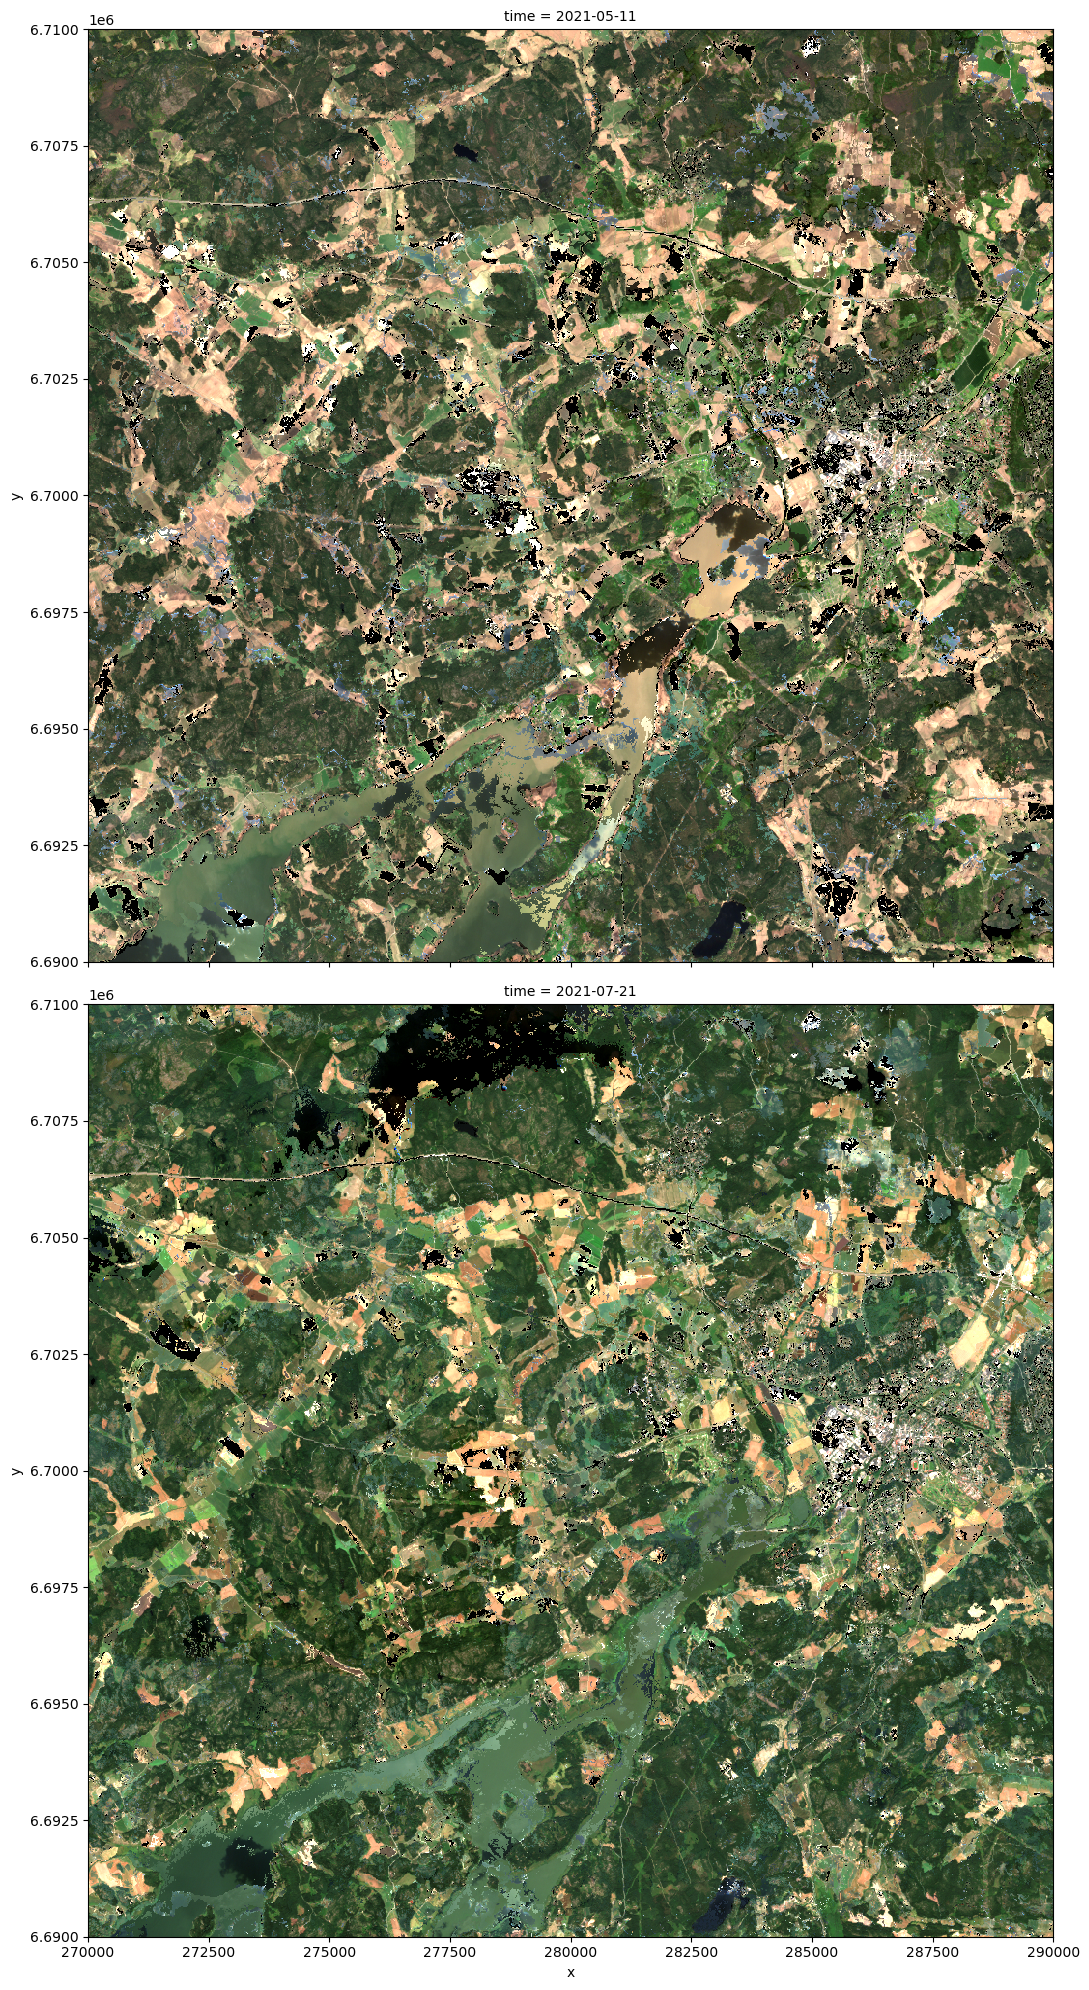

In [22]:
cube_2021_rgb = sentinel2[['b04', 'b03', 'b02']].isel(x=slice(1000,2000), y=slice(2000,3000))
cube_2021_rgb.to_array(dim="band").plot.imshow(row="time", rgb="band", robust=True, size=10)
cube_2021_rgb 



Stack different data from different dates just as bands for saving it to a file.

In [23]:
stacked = sentinel2.to_array(dim="band").stack(z=("band", "time"))
stacked

<xarray.DataArray (y: 3000, x: 10000, z: 8)> Size: 2GB
dask.array<reshape, shape=(3000, 10000, 8), dtype=float64, chunksize=(256, 256, 1), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
  * x            (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
    spatial_ref  int32 4B 3067
  * z            (z) object 64B MultiIndex
  * band         (z) object 64B 'b02' 'b02' 'b03' 'b03' 'b04' 'b04' 'b08' 'b08'
  * time         (z) datetime64[ns] 64B 2021-05-11 2021-07-21 ... 2021-07-21

Change the axis order for rasterio and add coordinate system info as rasterio wants to have it.

In [24]:
final = stacked.transpose('z', 'y', 'x')
final.rio.write_crs("epsg:3067", inplace=True)
final

<xarray.DataArray (z: 8, y: 3000, x: 10000)> Size: 2GB
dask.array<transpose, shape=(8, 3000, 10000), dtype=float64, chunksize=(1, 256, 256), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
  * x            (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
  * z            (z) object 64B MultiIndex
  * band         (z) object 64B 'b02' 'b02' 'b03' 'b03' 'b04' 'b04' 'b08' 'b08'
  * time         (z) datetime64[ns] 64B 2021-05-11 2021-07-21 ... 2021-07-21
    spatial_ref  int64 8B 0

Save image data to a file.

In [25]:
# Deep learning, model training
save_bbox_to_geotiff(final, x_min_3067_deep, y_min_3067, x_max_3067_deep, y_max_3067, cnn_data_training)
# Shallow learning, model training
save_bbox_to_geotiff(final, x_min_3067_shallow, y_min_3067_shallow, x_max_3067_shallow, y_max_3067_shallow, data_sentinel2)
# Validation
save_bbox_to_geotiff(final, x_min_3067_validation, y_min_3067, x_max_3067_validation, y_max_3067, cnn_data_validation)
# Test
save_bbox_to_geotiff(final, x_min_3067_test, y_min_3067, x_max_3067_test, y_max_3067, cnn_data_test)

## Google AlphaEarth data processing

Google AlphaEarth data is currently available via:

* [Google EarthEngine](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL), requires free account to the service. Provides functions to download bbox. Suits well for smaller areas.
* [Google Cloud Storage (GCS)](https://developers.google.com/earth-engine/guides/aef_on_gcs_readme) as COG-files in UTM zones folder structure. 
* [Source Cooperative](https://source.coop/tge-labs/aef)

GCS and Source Coopartive both provide index file as parquet, GeoPackage and CSV file. The index includes GCS or S3 links for data. Downloading from Source Cooperative was 3x faster when preparing for course, so we download from there. 

We can get the data with one GDAL command for our small area, but getting the file name is rather complicated. Even more, if the bbox is split to several map sheets or several UTM zones. Hopefully better tools (STAC?) will be available in the future.

Steps for getting the file name:
* Read the [Readme](https://source.coop/tge-labs/aef#manifest-and-index)
* Download [index file](https://source.coop/tge-labs/aef/v1/annual/aef_index.gpkg)
* Select in QGIS/Python relevant polygons, note the different years.
* GDAL can not use the TIFF files from Source Cooperative directly, but QGIS can. Use .vrt files to fix [the problem](https://source.coop/tge-labs/aef#object-object)
* Modify URLs from:
    * `s3://us-west-2.opendata.source.coop/tge-labs/aef/v1/annual/2021/34N/xg6o3outxe18szaej-0000008192-0000000000.tiff` to
    * `/vsicurl/https://data.source.coop/tge-labs/aef/v1/annual/2021/34N/xg6o3outxe18szaej-0000008192-0000000000.vrt`
      
Settings of `gdalwarp`
* `-t_srs` - coordinate system of result file
* `-te` - bbox
* `-tr` - pixel size
* `-r` - resampling method
* `AWS_NO_SIGN_REQUEST=YES` in front of the GDAL command to make the download work. The .vrt file has HTTPS link, but the .vrt has link to .tif file as S3...


In [26]:
! AWS_NO_SIGN_REQUEST=YES gdalwarp \
  -t_srs EPSG:3067 \
  -te {x_min_3067_shallow} {y_min_3067_shallow} {x_max_3067_shallow} {y_max_3067_shallow} \
  -tr 20 20 \
  -r average \
  /vsicurl/https://data.source.coop/tge-labs/aef/v1/annual/2021/34N/xg6o3outxe18szaej-0000008192-0000008192.vrt \
  {data_alphaearth}

Creating output file that is 1000P x 1000L.
Using internal nodata values (e.g. -128) for image /vsicurl/https://data.source.coop/tge-labs/aef/v1/annual/2021/34N/xg6o3outxe18szaej-0000008192-0000008192.vrt.
Copying nodata values from source /vsicurl/https://data.source.coop/tge-labs/aef/v1/annual/2021/34N/xg6o3outxe18szaej-0000008192-0000008192.vrt to destination /scratch/project_2019932/students/ekkylli/GeoML/data/raster/pixel-wise/data_alphaearth.tif.
Processing xg6o3outxe18szaej-0000008192-0000008192.vrt [1/1] : ]9;4;1;2]9;4;1;5]9;4;1;7]9;4;1;10]9;4;1;12]9;4;1;15]9;4;1;17]9;4;1;20]9;4;1;22]9;4;1;25]9;4;1;27]9;4;1;30]9;4;1;32]9;4;1;35]9;4;1;37]9;4;1;40]9;4;1;42]9;4;1;45]9;4;1;47]9;4;1;50]9;4;1;52]9;4;1;55]9;4;1;57]9;4;1;60]9;4;1;62]9;4;1;65]9;4;1;67]9;4;1;70]9;4;1;72]9;4;1;75]9;4;1;77]9;4;1;80]9;4;1;82]9;4;1;85]9;4;1;87]9;4;1;90]9;4;1;92]9;4;1;95]9;4;1;97]9;4;0;1000...10...20...30...40...50...60...70...80.

In [27]:
# Same command for Goolge Cloud storage
#! gdalwarp \
#  -t_srs EPSG:3067 \
#  -te 270000 6690000 290000 6710000 \
#  -tr 20 20 \
#  -r average \
#  /vsicurl/https://storage.googleapis.com/alphaearth_foundations/satellite_embedding/v1/annual/2021/34N/xg6o3outxe18szaej-0000008192-0000008192.tiff \
#  {data_alphaearth}

The AlphaEarth data has still Integer data type with data values between -127 and 127. -128 is reserved as the "no data" value. The transformation to -1 to 1 is done in the next exercises. This enables keeping the file size on disk much smaller. 

## Results

The data preparations for classification exercises are now ready, check `../data/raster` folder, that you have 3 .tif files in `pixel-wise` folder and 6 files in `cnn` folder. Therea are also .tif.aux.xml files, which GDAL creates automatically with some metadata of the raster files.